In [32]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [34]:
from src.data import load_train_test

train, test = load_train_test()

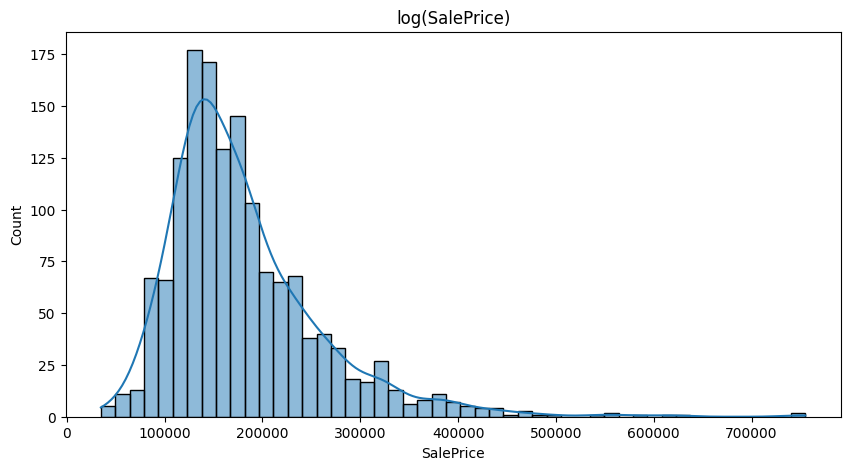

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("log(SalePrice)")
plt.show()

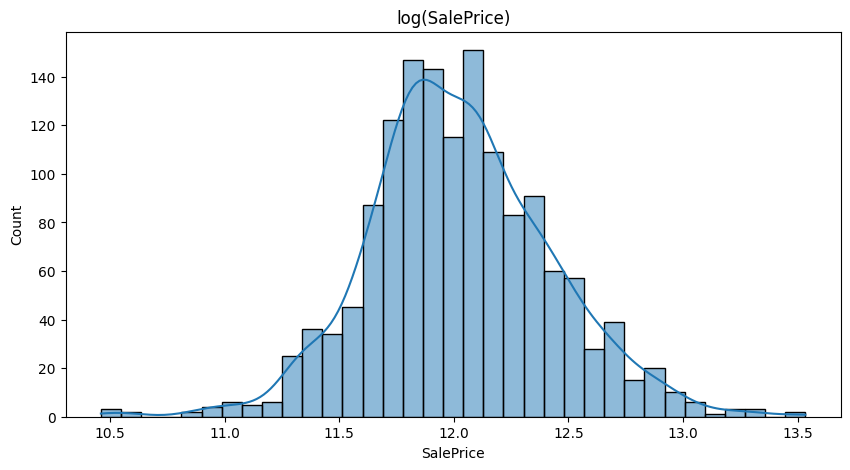

In [36]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(train["SalePrice"]), kde=True)
plt.title("log(SalePrice)")
plt.show()

In [37]:
missing_percent = (train.isna().mean() * 100).sort_values(ascending=False)
missing_percent.head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

## Вывод по пропускам

В датасете есть признаки, где `NaN` не обязательно означает ошибку в данных.

Для некоторых признаков пропуск означает отсутствие объекта:

- `GarageType`, `GarageFinish`, `GarageQual` -- отсутствие гаража;
- `BsmtQual`, `BsmtCond`, `BsmtExposure` -- отсутствие подвала;
- `FireplaceQu` -- отсутствие камина;
- `PoolQC` -- отсутствие бассейна;
- `Fence` -- отсутствие забора.

Поэтому на этапе feature engineering такие пропуски лучше выделять в отдельную категорию `"None"`.

In [38]:
numeric_features = train.select_dtypes(include=["int64", "float64"]).columns

corr = train[numeric_features].corr()
corr_with_target = corr["SalePrice"].sort_values(ascending=False)
corr_with_target.head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

## Вывод по корреляциям

Наиболее сильная связь с `SalePrice` наблюдается у признаков, связанных с качеством и площадью дома:

- `OverallQual`;
- `GrLivArea`;
- `GarageCars`;
- `GarageArea`;
- `TotalBsmtSF`;
- `1stFlrSF`.

На этапе feature engineering имеет смысл добавить агрегированные признаки, например общую площадь дома (`TotalSF`) и общее количество ванных комнат (`TotalBath`).

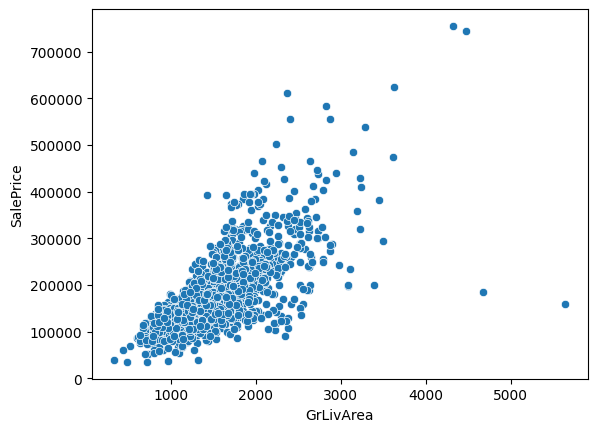

In [39]:
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.show()

## Вывод по выбросам

На графике `GrLivArea` vs `SalePrice` видны объекты с очень большой жилой площадью, но относительно низкой ценой.

Такие наблюдения могут ухудшать обучение модели и влиять на локальную cross-validation.

На этапе feature engineering будет проведён отдельный эксперимент с удалением этих выбросов. При этом важно сравнить не только CV score, но и результат на Kaggle.

In [40]:
categorical_features = train.select_dtypes(include=["object"]).columns
len(categorical_features)

43

## Итоги EDA
+ Цена ассиметрична, поэтому принято решение использовать log1p
+ Много пропусков, но часто это просто присутствие/отсутствие чего либо
+ Наиболее важные признаки: OverallQual, GrLivArea, GarageCars
+ Есть выбросы, от которых стоит избавиться позже для улучшения модели